In [2]:
import pandas as pd
df=pd.read_csv('data.csv')

In [4]:
print("Checking the shape of the dataset...")
print(df.shape)
print("Checking if there are null values...")
print(df.isnull().sum())
print("Checking if there are any duplicates...")
print(df.keys())
print(df.Hf)
df.describe()

Checking the shape of the dataset...
(70, 15)
Checking if there are null values...
MXene    0
EGWg     0
EPBEg    0
φL       0
φU       0
d        0
∆d       0
V        0
APF      0
EV       0
EC       0
φN       0
a        0
c        0
Hf       0
dtype: int64
Checking if there are any duplicates...
Index(['MXene', 'EGWg', 'EPBEg', 'φL', 'φU', 'd', '∆d', 'V', 'APF', 'EV', 'EC',
       'φN', 'a', 'c', 'Hf'],
      dtype='object')
0    -11.2764
1    -10.6495
2    -12.6013
3     -9.9570
4    -10.5544
       ...   
65   -13.2859
66   -10.5032
67   -11.0999
68   -10.6379
69   -11.3372
Name: Hf, Length: 70, dtype: float64


,EGWg,EPBEg,φL,φU,d,∆d,V,APF,EV,EC,φN,a,c,Hf
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,2.433434,0.936464,2.018747,4.599370,2.406267,0.032930,46.829944,0.333794,-5.103444,-4.166974,3.309461,3.517453,0.957143,-10.691054
std,0.377458,0.132081,1.215041,1.419435,0.066481,0.129483,10.971596,0.080267,1.753384,1.736918,0.843567,0.102522,0.203997,2.929103
min,1.586700,0.702400,-1.097800,1.554600,2.280600,-0.110800,29.685600,0.222200,-9.764900,-9.062500,1.554400,3.293700,0.000000,-17.594900
25%,2.283050,0.844375,1.401725,3.277975,2.341200,-0.055275,38.419250,0.269525,-5.890425,-4.959825,2.624700,3.447125,1.000000,-12.656275
50%,2.401250,0.925100,2.015250,4.572950,2.422300,-0.041550,44.849550,0.313900,-5.256200,-4.271900,3.233950,3.530950,1.000000,-10.643700
75%,2.571175,1.026250,3.073600,5.666350,2.440075,0.203625,56.230075,0.376400,-3.802400,-2.939150,4.135375,3.575400,1.000000,-8.430825
max,3.395600,1.378100,4.603300,8.333400,2.570600,0.264300,69.386600,0.537100,-2.059800,-1.259300,4.930200,3.774800,1.000000,-6.311800


In [29]:
# Filter out semiconductors
mask = df["EPBEg"] > 0
df = df[mask]
df.head()

exclude = ["MXene"]
df_train = df.drop(exclude, axis=1)
df_train.head()

#import seaborn as sns
#import matplotlib.pyplot as plt
#plt.figure(figsize=(14,8))
#corr=df1.corr()
#sns.heatmap(corr, cmap='gnuplot')

,EGWg,EPBEg,φL,φU,d,∆d,V,APF,EV,EC,φN,a,c,Hf
0,3.3956,0.8756,2.1713,6.3336,2.4302,-0.0512,39.0152,0.3661,-5.6868,-4.8112,4.2524,3.5492,1,-11.2764
1,3.3659,0.8269,2.1340,6.3941,2.4424,-0.0634,39.7189,0.3667,-5.4308,-4.6039,4.2641,3.5791,1,-10.6495
2,3.3072,0.9249,3.3325,4.5681,2.4290,-0.0500,39.0158,0.3661,-4.0290,-3.1041,3.9504,3.5509,1,-12.6013
3,3.2661,0.9253,2.9483,3.2084,2.4139,-0.0349,38.2206,0.3786,-3.2805,-2.3552,3.0783,3.5155,1,-9.9570
4,3.2553,0.8181,3.0055,4.3419,2.4407,-0.0617,39.6260,0.3724,-3.1205,-2.3024,3.6737,3.5785,1,-10.5544


In [41]:
# Prepare X/Y 
X = df_train.drop(["EGWg"], axis=1)
Y = df_train["EGWg"].values

# Split into train/test sets
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=1)

print(X_train.shape, Y_train.shape)
print(X_test.shape, X_test.shape)

(63, 13) (63,)
(7, 13) (7, 13)


In [43]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

models = []
models.append(("LinearRegression", LinearRegression()))
models.append(("DecisionTreeRegressor", DecisionTreeRegressor()))
models.append(("RandomForestRegressor", RandomForestRegressor(random_state=1)))

for name, model in models:
    
    print("----------------------------------")
    model.fit(X_train, Y_train)
    print(f"Evaluate {name} Model")
    R2 = round(model.score(X_test, Y_test), 3)
    RMSE = np.sqrt(mean_squared_error(y_true=Y_test, y_pred=model.predict(X_test))).round(decimals=3)
    print(f"Testing R2 = {R2}")
    print(f"Testing RMSE = {RMSE}")

----------------------------------
Evaluate LinearRegression Model
Testing R2 = -0.903
Testing RMSE = 0.347
----------------------------------
Evaluate DecisionTreeRegressor Model
Testing R2 = -7.578
Testing RMSE = 0.736
----------------------------------
Evaluate RandomForestRegressor Model
Testing R2 = -0.852
Testing RMSE = 0.342


In [44]:
from sklearn.model_selection import GridSearchCV

n_estimators = [100, 200, 300, 400] # number of random trees
max_depth = [2, 4, 8, 16] # number of depth for which tree grows
parameters = {"n_estimators": n_estimators, "max_depth": max_depth}

name = "RandomForestRegressor"
model = RandomForestRegressor(random_state=1)

gscv = GridSearchCV(model, parameters, scoring="neg_mean_squared_error")
gscv.fit(X_train, Y_train)

best = gscv.best_estimator_

best.fit(X_train, Y_train)
print(f"Evaluate Best {name} Model")
R2 = best.score(X_test, Y_test).round(decimals=3)
RMSE = np.sqrt(mean_squared_error(y_true=Y_test, y_pred=best.predict(X_test))).round(decimals=3)
print(f"R2 Score = {R2}")
print(f"RMSE Score = {RMSE}")

Evaluate Best RandomForestRegressor Model
R2 Score = -0.692
RMSE Score = 0.327


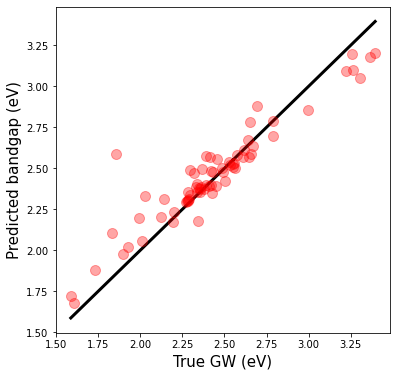

In [45]:
import matplotlib.pyplot as plt

Y_pred = best.predict(X)

plt.subplots(figsize=(6, 6))

plt.plot(Y, Y, "k", lw=3)
plt.plot(Y, Y_pred, "ro", ms=10, alpha=0.35)
plt.xlabel("True GW (eV)", fontsize=15)
plt.ylabel("Predicted bandgap (eV)", fontsize=15)

plt.show()